In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import warnings
import pickle as pkl
import sccoda

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import tensorflow as tf
tf.random.set_seed(1)  # setting the same seed makes multiple runs of scCODA exactly reproducible

warnings.filterwarnings("ignore")

basedir = "/mnt/raid5/20200923 HTAPP combined data/scCODA/"

#resolution = "fine"  # use fine or coarse resolution to define cell types
resolution = "coarse"
countsfile = f"{basedir}/neuroblastoma_scCODA_annotate_refine_{resolution}_counts_cleaned_malcombined.csv"
#"cleaned" file has erythrocytes and zona glomerulosa cell counts removed

model_specs = [("Treatment_Status", "C(Treatment_Status, Treatment('untreated'))"),
               ("Treatment_Status", "C(Treatment_Status, Treatment('treated_chemotherapy'))"),
               ("Treatment_Status", "C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))")]

In [2]:
# Read counts file into scCODA
cell_counts = pd.read_csv(countsfile, skip_blank_lines = True)
#sampletracking.dropna(axis=0, how='all', inplace = True)
cell_counts = cell_counts.drop(columns=['Unnamed: 0'])

first_covariate_index = cell_counts.columns.tolist().index('orig.ident')
cell_counts.columns[first_covariate_index:]

# Subset counts data to only look at nucleus samples
# cell_counts = cell_counts[cell_counts['condition'] == "nucleus"]
cell_counts.head()

data_nb = dat.from_pandas(cell_counts, covariate_columns=cell_counts.columns[first_covariate_index:])
print(data_nb.X)
print(data_nb.obs)

#remove "unknown" treatment status groups and narrow to high risk
data_nb = data_nb[data_nb.obs["COG_Risk"].isin(["High"])]
data_nb = data_nb[data_nb.obs["Treatment_Status"].isin(["untreated", "treated_chemotherapy", "treated_chemo-immunotherapy"])]

print(data_nb.obs)

[[2.7290e+03 8.4500e+02 1.8040e+03 8.4000e+02]
 [6.1300e+02 3.2900e+02 6.9350e+03 2.8400e+02]
 [2.1600e+03 6.5200e+02 4.2480e+03 4.9000e+02]
 [6.8300e+02 3.2000e+02 7.5870e+03 1.8900e+02]
 [8.3100e+02 1.8290e+03 2.8470e+03 2.6970e+03]
 [3.4600e+02 1.1500e+02 6.3960e+03 2.4500e+02]
 [8.0200e+02 1.4790e+03 3.8040e+03 2.5400e+02]
 [6.5200e+02 5.9840e+03 4.9240e+03 5.1260e+03]
 [1.7080e+03 1.6900e+02 5.1730e+03 1.9700e+02]
 [7.3000e+01 2.0000e+01 7.3520e+03 0.0000e+00]
 [3.9960e+03 1.0410e+03 7.7810e+03 1.1430e+03]
 [2.6400e+02 3.3800e+02 7.6140e+03 1.9200e+02]
 [9.5000e+01 4.3000e+01 6.0060e+03 1.3700e+02]
 [5.7840e+03 6.3300e+02 1.5850e+03 8.9800e+02]
 [1.5390e+03 4.2700e+02 1.0334e+04 1.5100e+02]
 [1.1790e+03 1.3530e+03 4.3660e+03 3.4260e+03]
 [6.3500e+02 2.6400e+02 7.0670e+03 0.0000e+00]
 [8.5000e+01 1.0900e+02 6.8020e+03 0.0000e+00]
 [1.1130e+03 1.7960e+03 2.7800e+02 5.2200e+02]
 [1.9800e+02 3.2000e+01 2.5010e+03 4.9000e+01]
 [1.0420e+03 2.7800e+02 2.6410e+03 8.9000e+01]
 [1.1900e+03 

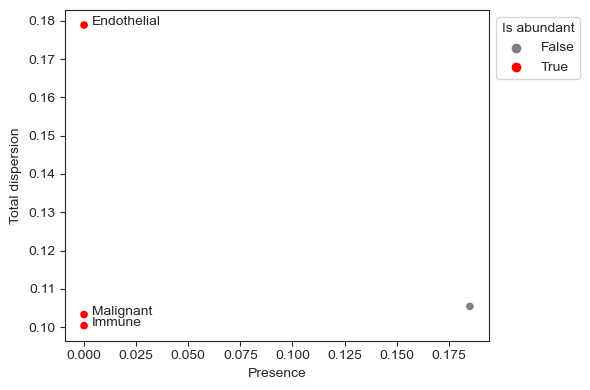

In [3]:
viz.rel_abundance_dispersion_plot(
    data=data_nb,
    abundant_threshold=0.9
)
plt.show()

feature: Treatment_Status
formula: C(Treatment_Status, Treatment('untreated'))
Reference: Immune


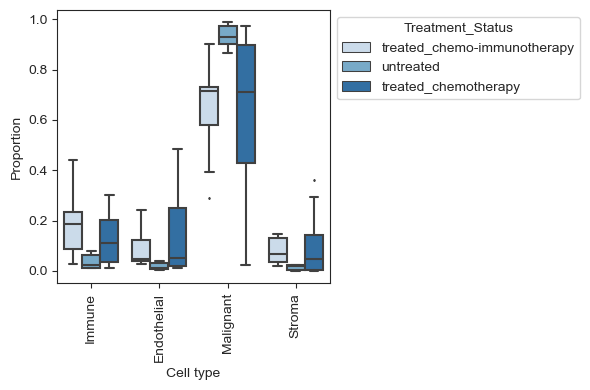

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.008 sec)
Acceptance rate: 56.3%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.077       288.923297
Endothelial           -0.351       219.677650
Malignant              3.138      7195.141213
Stroma                -0.801       140.072654


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant          -1.787029   
                           

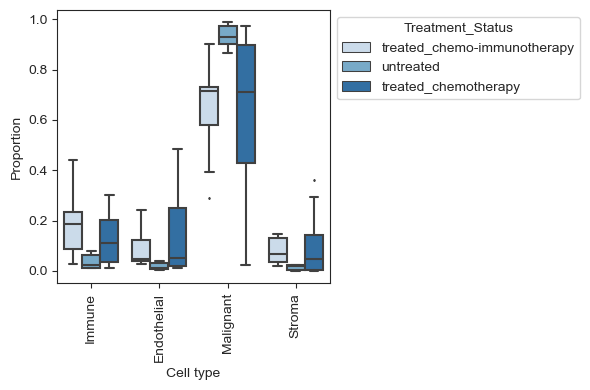

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (131.141 sec)
Acceptance rate: 54.2%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                 0.121       317.128767
Endothelial           -0.340       199.998106
Malignant              3.243      7196.196467
Stroma                -0.767       130.491475


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant          -1.750251   
                           

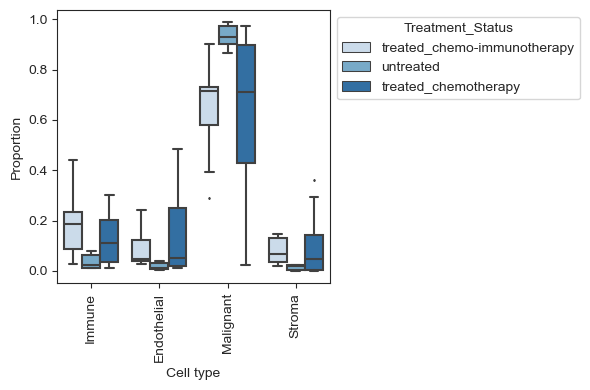

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.829 sec)
Acceptance rate: 56.3%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.616      1026.088581
Endothelial           -0.878       789.586475
Malignant              1.054      5450.754718
Stroma                -1.191       577.385041


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... Immune              0.688424   
                                                   Endothelial         0.612871   
                                                   Malignant           0.000000   
                           

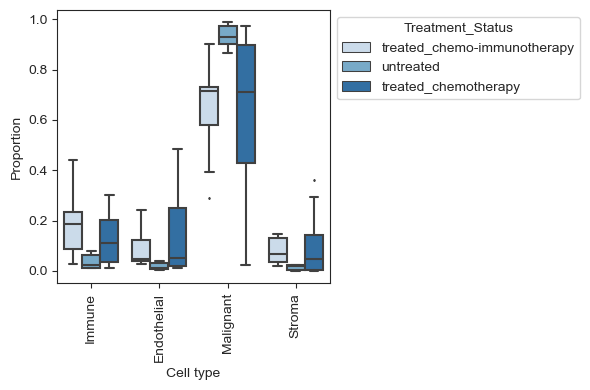

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.401 sec)
Acceptance rate: 69.3%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                 0.032       296.307947
Endothelial           -0.324       207.555604
Malignant              3.224      7211.262182
Stroma                -0.802       128.689082


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant          -1.843109   
                           

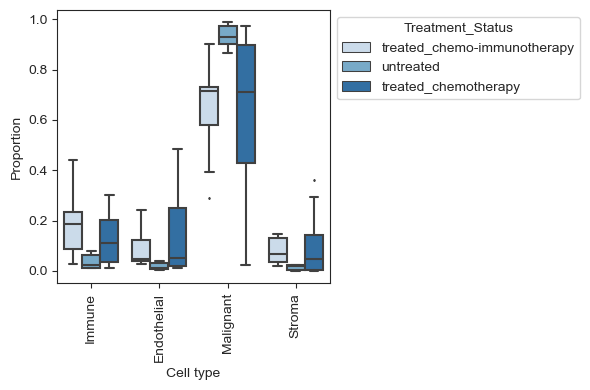

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (128.790 sec)
Acceptance rate: 43.1%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.089      1638.056016
Endothelial           -0.391      1211.077165
Malignant              0.875      4295.251812
Stroma                -0.940       699.429821


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant           0.563212   
                

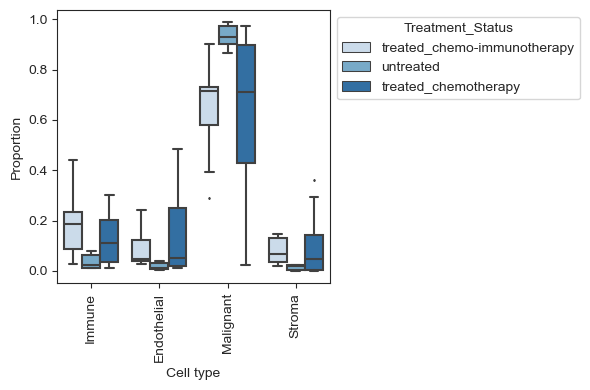

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (131.236 sec)
Acceptance rate: 53.7%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.289      1478.770676
Endothelial           -0.347      1395.441871
Malignant              0.771      4268.280779
Stroma                -1.035       701.321489


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... Immune              0.840962   
                                                   Endothelial         0.000000   
                                                   Malignant           0.899144   
                

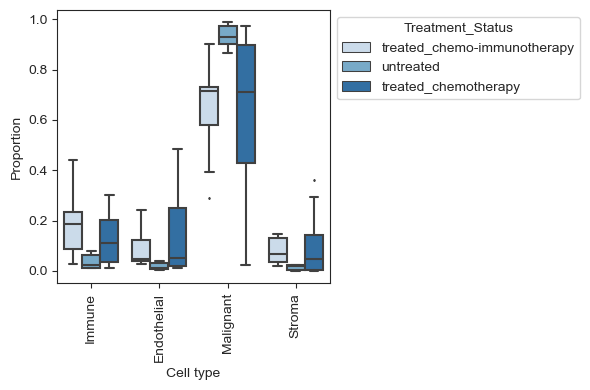

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.702 sec)
Acceptance rate: 59.3%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.317      1266.272215
Endothelial           -0.510      1044.018616
Malignant              1.034      4889.437764
Stroma                -0.993       644.086220


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant           0.000000   
                

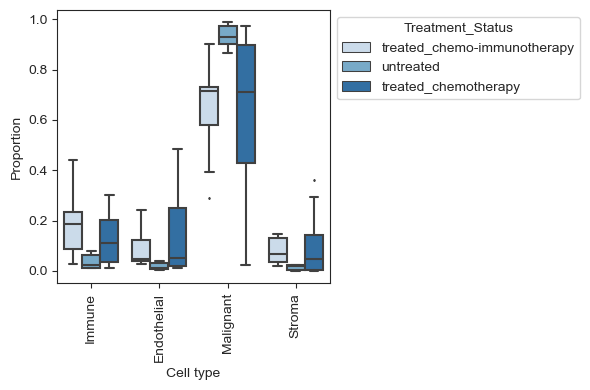

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.862 sec)
Acceptance rate: 51.7%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.188      1520.363243
Endothelial           -0.414      1212.821280
Malignant              0.853      4305.741145
Stroma                -0.824       804.889146


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant           0.579481   
                

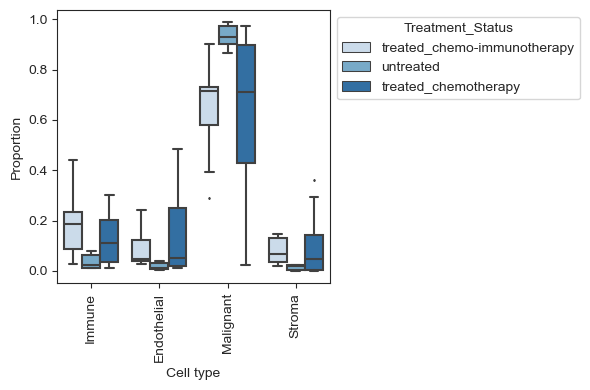

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (129.309 sec)
Acceptance rate: 50.8%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.092      1403.891770
Endothelial           -0.371      1062.100144
Malignant              1.105      4647.122523
Stroma                -0.745       730.700377


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... Immune               0.00000   
                                                   Endothelial          0.00000   
                                                   Malignant            0.00000   
         

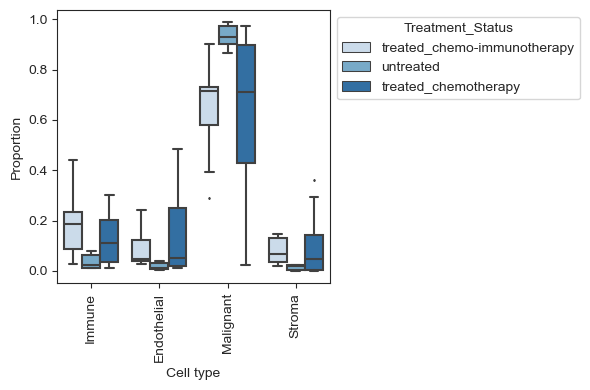

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (131.078 sec)
Acceptance rate: 54.2%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                 0.083      1487.069835
Endothelial           -0.351       963.490771
Malignant              1.228      4673.029751
Stroma                -0.642       720.224457


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... Immune             -0.574795   
                                                   Endothelial         0.000000   
                                                   Malignant          -0.740452   
         

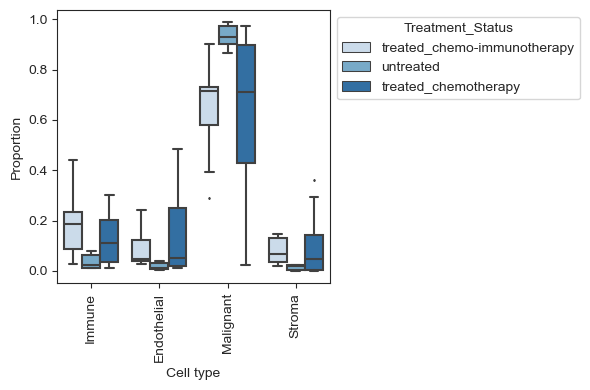

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.887 sec)
Acceptance rate: 54.6%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.110      1431.584237
Endothelial           -0.427      1042.666828
Malignant              1.048      4557.534007
Stroma                -0.677       812.029743


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant           0.000000   
         

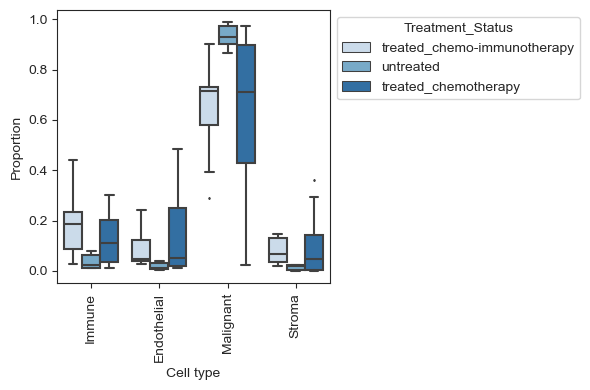

Zero counts encountered in data! Added a pseudocount of 0.5.
MCMC sampling finished. (130.719 sec)
Acceptance rate: 64.6%
Compositional Analysis summary:

Data: 27 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
Immune                -0.011      1459.967202
Endothelial           -0.360      1029.850835
Malignant              1.158      4699.301927
Stroma                -0.813       654.694851


Effects:
                                                                Final Parameter  \
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... Immune              0.000000   
                                                   Endothelial         0.000000   
                                                   Malignant          -0.634815   
         

In [4]:
tf.random.set_seed(1)

i = 0
feature = model_specs[i][0]
formula = model_specs[i][1]

cell_types = data_nb.var.index

for feature, formula in model_specs:
    #results_cycle = pd.DataFrame(index=cell_types, columns=["times_credible"]).fillna(0)
    for ct in cell_types:
        print(f"feature: {feature}")
        print(f"formula: {formula}")
        print(f"Reference: {ct}")

        viz.boxplots(data_nb, feature_name=feature, plot_facets=False, y_scale="relative", add_dots=False)
        plt.savefig(f"{basedir}results/{feature}_{resolution}.pdf", bbox_inches="tight")
        plt.show()
        
        # Run inference
        model_temp = mod.CompositionalAnalysis(data_nb, formula=formula, reference_cell_type=ct)
        temp_results = model_temp.sample_hmc()
        temp_results.summary()
        print(temp_results.credible_effects())
                     
        # Select credible effects
        #cred_eff = temp_results.credible_effects()
        #cred_eff.index = cred_eff.index.droplevel(level=0)
        
        # add up credible effects'
        #results_cycle["times_credible"] += cred_eff.astype("int")
        
    #results_cycle["pct_credible"] = results_cycle["times_credible"]/len(cell_types)
    #results_cycle["is_credible"] = results_cycle["pct_credible"] > 0.5
    #print(results_cycle)